#### Statement of use of AI

AI was used to fix the errors in the code and mainly for guidance on what happened in the code, why it did not work, and also help to write SQL queries. The AI helped explain concepts, I reviewed, tested, and adapted all code to ensure I understood how it works and that it meets the assignment requirements.

#### Task 0: Course project dataset exploration
##### a) Dataset choice
Dataset name: Financials Dataset  
Source: Kaggle  
Link: https://www.kaggle.com/datasets/atharvaarya25/financials

##### b) Dataset description
The dataset contains financial information for multiple companies across several years and is suitable for financial analysis and exploratory data analysis. It includes key financial variables such as revenue, profit, and other indicators.

Each row represents a company’s financial performance in a given year.
The dataset includes both numerical and categorical variables, allowing for analysis of company performance across time and between firms.

The dataset contains 700 rows and 16 columns (the code is below).

##### Project idea

In this project, I plan to analyze financial performance across companies, explore the relationship between revenue and profit, examine trends over time, and compare performance across companies.

In [10]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 700
Columns: 16


In [2]:
# c)
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

df = pd.read_csv("data/Financials.csv")
display(df.head())

,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Month Name,Year
0,Government,Canada,Carretera,None,"$1,618.50",$3.00,$20.00,"$32,370.00",$-,"$32,370.00","$16,185.00","$16,185.00",01/01/2014,1,January,2014
1,Government,Germany,Carretera,None,"$1,321.00",$3.00,$20.00,"$26,420.00",$-,"$26,420.00","$13,210.00","$13,210.00",01/01/2014,1,January,2014
2,Midmarket,France,Carretera,None,"$2,178.00",$3.00,$15.00,"$32,670.00",$-,"$32,670.00","$21,780.00","$10,890.00",01/06/2014,6,June,2014
3,Midmarket,Germany,Carretera,None,$888.00,$3.00,$15.00,"$13,320.00",$-,"$13,320.00","$8,880.00","$4,440.00",01/06/2014,6,June,2014
4,Midmarket,Mexico,Carretera,None,"$2,470.00",$3.00,$15.00,"$37,050.00",$-,"$37,050.00","$24,700.00","$12,350.00",01/06/2014,6,June,2014


In [3]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

Shape: (700, 16)

Columns:
Index(['Segment', 'Country', ' Product ', ' Discount Band ', ' Units Sold ',
       ' Manufacturing Price ', ' Sale Price ', ' Gross Sales ', ' Discounts ',
       '  Sales ', ' COGS ', ' Profit ', 'Date', 'Month Number',
       ' Month Name ', 'Year'],
      dtype='object')

Data types:
Segment                  object
Country                  object
 Product                 object
 Discount Band           object
 Units Sold              object
 Manufacturing Price     object
 Sale Price              object
 Gross Sales             object
 Discounts               object
  Sales                  object
 COGS                    object
 Profit                  object
Date                     object
Month Number              int64
 Month Name              object
Year                      int64
dtype: object


In [13]:
df.columns = df.columns.str.strip()
print(df.columns)

Index(['Segment', 'Country', 'Product', 'Discount Band', 'Units Sold',
       'Manufacturing Price', 'Sale Price', 'Gross Sales', 'Discounts',
       'Sales', 'COGS', 'Profit', 'Date', 'Month Number', 'Month Name',
       'Year'],
      dtype='object')


In [4]:
display(df.describe())

,Month Number,Year
count,700.000000,700.000000
mean,7.900000,2013.750000
std,3.377321,0.433322
min,1.000000,2013.000000
25%,5.750000,2013.750000
50%,9.000000,2014.000000
75%,10.250000,2014.000000
max,12.000000,2014.000000


In [5]:
display(df.isna().sum())

Segment                  0
Country                  0
 Product                 0
 Discount Band           0
 Units Sold              0
 Manufacturing Price     0
 Sale Price              0
 Gross Sales             0
 Discounts               0
  Sales                  0
 COGS                    0
 Profit                  0
Date                     0
Month Number             0
 Month Name              0
Year                     0
dtype: int64

In [26]:
# Visualization 1: Sales by product across countries
df.columns = df.columns.str.strip()
df["Sales"] = df["Sales"].replace('[\$,]', '', regex=True).astype(float) #clean the data

sales_by_country_product = df.groupby(["Country", "Product"])["Sales"].sum().reset_index() #group the data

pivot_table = sales_by_country_product.pivot(index="Country", columns="Product", values="Sales") #pivot the data

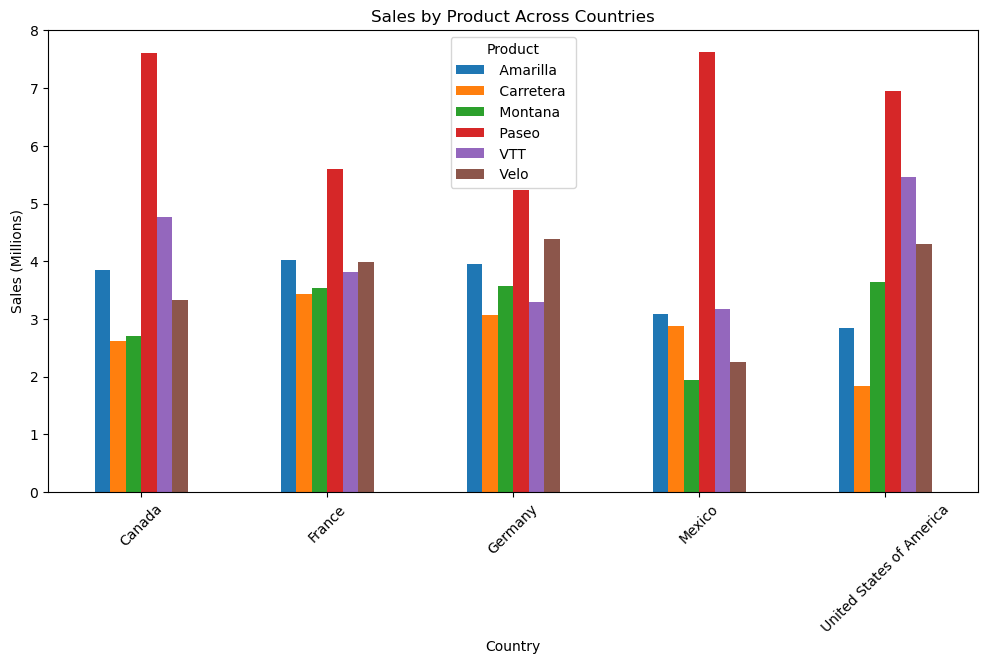

In [30]:
# Grouped bar chart
import matplotlib.pyplot as plt

pivot_table_millions = pivot_table / 1_000_000

pivot_table_millions.plot(kind="bar", figsize=(12,6))

plt.title("Sales by Product Across Countries")
plt.xlabel("Country")
plt.ylabel("Sales (Millions)")
plt.xticks(rotation=45)

plt.show()

In [38]:
# Visualization 2: Sales, COGS, Profit by product
df.columns = df.columns.str.strip()

cols = ["Sales", "COGS", "Profit"]

for col in cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.strip()
    )
    df[col] = pd.to_numeric(df[col], errors="coerce")

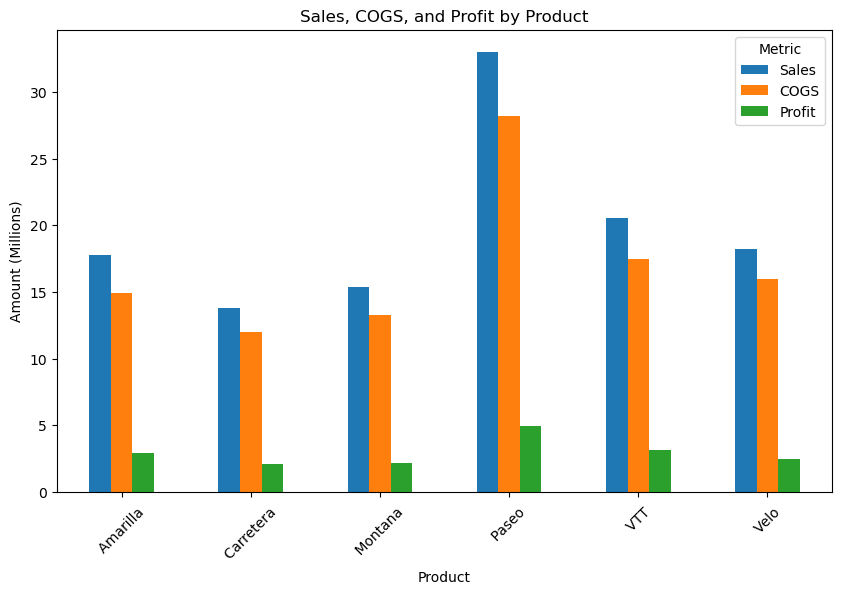

In [39]:
# Grouped bar chart
product_summary = df.groupby("Product")[["Sales", "COGS", "Profit"]].sum()

product_summary_millions = product_summary / 1_000_000

product_summary_millions.plot(kind="bar", figsize=(10, 6))

plt.title("Sales, COGS, and Profit by Product")
plt.xlabel("Product")
plt.ylabel("Amount (Millions)")
plt.xticks(rotation=45)
plt.legend(title="Metric")
plt.show()

#### Task 1: Setting up an API key and .env file

In [1]:
from dotenv import load_dotenv
import os

load_dotenv()
api_key = os.getenv("MARKETSTACK_API_KEY")

print(api_key[:5] + "...")

4533a...


#### Task 2: Retrieving data from MarketStack

In [1]:
# a) and b)
import os
import requests
import pandas as pd
from dotenv import load_dotenv
from IPython.display import display

In [2]:
# Load API key from .env
load_dotenv()
api_key = os.getenv("MARKETSTACK_API_KEY")

print(api_key[:5] + "...")

4533a...


In [3]:
# FAANG tickers for this task
symbols = ["META", "AAPL", "AMZN", "NFLX", "GOOG"]

url = "https://api.marketstack.com/v2/eod"

params = {
    "access_key": api_key,
    "symbols": ",".join(symbols),
    "date_from": "2026-03-01",
    "date_to": "2026-03-31",
    "sort": "ASC",
    "limit": 1000
}

response = requests.get(url, params=params)
data = response.json()

# Check for API errors
if "error" in data:
    print("API error:")
    print(data["error"])
else:
    print("Request successful.")
    print("Number of records returned:", len(data["data"]))

Request successful.
Number of records returned: 110


In [4]:
# Convert JSON data to DataFrame
df_market = pd.DataFrame(data["data"])

# Show first 5 rows
display(df_market.head())

,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,name,exchange_code,asset_type,price_currency,symbol,exchange,date
0,262.44,266.53,260.20,264.72,41576035.0,266.53,260.20,264.72,262.410,41827946.0,1.0,0.0,Apple Inc,NASDAQ,Stock,USD,AAPL,XNAS,2026-03-02T00:00:00+0000
1,204.55,209.72,203.48,208.39,43410499.0,209.73,203.46,208.39,204.550,46001010.0,1.0,0.0,Amazon.com Inc,NASDAQ,Stock,USD,AMZN,XNAS,2026-03-02T00:00:00+0000
2,302.93,308.14,301.06,306.36,21789144.0,308.14,301.06,306.36,302.965,21854368.0,1.0,0.0,1X GOOG,None,ETF,EUR,GOOG,XNAS,2026-03-02T00:00:00+0000
3,637.16,659.94,634.50,653.56,9801700.0,659.94,634.50,653.56,637.160,9816125.0,1.0,0.0,"Meta Platforms, Inc.",None,Stock,ARS,META,ARCX,2026-03-02T00:00:00+0000
4,95.33,98.07,95.25,97.09,79614084.0,98.07,95.20,97.09,95.260,79915361.0,1.0,0.0,NETFLIX INC,None,None,MXN,NFLX,XNAS,2026-03-02T00:00:00+0000


In [5]:
print(df_market.columns)
print(df_market.dtypes)

Index(['open', 'high', 'low', 'close', 'volume', 'adj_high', 'adj_low',
       'adj_close', 'adj_open', 'adj_volume', 'split_factor', 'dividend',
       'name', 'exchange_code', 'asset_type', 'price_currency', 'symbol',
       'exchange', 'date'],
      dtype='object')
open              float64
high              float64
low               float64
close             float64
volume            float64
adj_high          float64
adj_low           float64
adj_close         float64
adj_open          float64
adj_volume        float64
split_factor      float64
dividend          float64
name               object
exchange_code      object
asset_type         object
price_currency     object
symbol             object
exchange           object
date               object
dtype: object


In [6]:
# c)
# Keep only useful columns for this task
market = df_market[["symbol", "date", "open", "high", "low", "close", "volume"]].copy()

# Convert date column to datetime
market["date"] = pd.to_datetime(market["date"])

# Sort by stock and date
market = market.sort_values(["symbol", "date"])

display(market.head())

,symbol,date,open,high,low,close,volume
0,AAPL,2026-03-02 00:00:00+00:00,262.440,266.530,260.20,264.72,41576035.0
5,AAPL,2026-03-03 00:00:00+00:00,263.480,265.560,260.13,263.75,37994695.0
10,AAPL,2026-03-04 00:00:00+00:00,264.650,266.150,261.42,262.52,39258957.0
15,AAPL,2026-03-05 00:00:00+00:00,260.745,261.555,257.25,260.29,49424671.0
20,AAPL,2026-03-06 00:00:00+00:00,258.740,258.760,254.37,257.46,40628988.0


In [7]:
# Summary statistics for closing prices grouped by stock
summary_stats = market.groupby("symbol")["close"].describe()

print("Summary statistics for closing prices:")
display(summary_stats)

Summary statistics for closing prices:


,count,mean,std,min,25%,50%,75%,max
symbol,,,,,,,,
AAPL,22.0,254.906364,5.510351,246.63,250.4625,253.340,260.1875,264.72
AMZN,22.0,209.995000,4.643217,199.34,207.8200,209.700,213.0700,218.94
GOOG,22.0,297.980455,10.928636,273.14,291.7675,302.335,305.9400,309.41
META,22.0,614.990909,41.309579,525.72,593.9675,619.170,652.0175,667.73
NFLX,22.0,95.076364,2.512109,90.92,93.3350,94.795,97.0525,99.17


In [8]:
# Monthly return = percentage change from first trading day close to last trading day close
monthly_returns = (
    market.groupby("symbol")
    .agg(
        first_close=("close", "first"),
        last_close=("close", "last")
    )
)

monthly_returns["return_pct"] = (
    (monthly_returns["last_close"] - monthly_returns["first_close"])
    / monthly_returns["first_close"]
) * 100

print("Monthly returns in March 2026:")
display(monthly_returns)

Monthly returns in March 2026:


,first_close,last_close,return_pct
symbol,,,
AAPL,264.72,253.79,-4.128891
AMZN,208.39,208.27,-0.057584
GOOG,306.36,286.86,-6.365061
META,653.56,572.13,-12.459453
NFLX,97.09,96.15,-0.968174


In [9]:
# Best and worst performer
best_stock = monthly_returns["return_pct"].idxmax()
worst_stock = monthly_returns["return_pct"].idxmin()

best_return = monthly_returns.loc[best_stock, "return_pct"]
worst_return = monthly_returns.loc[worst_stock, "return_pct"]

print(f"Best performer in March 2026: {best_stock} ({best_return:.2f}%)")
print(f"Worst performer in March 2026: {worst_stock} ({worst_return:.2f}%)")

Best performer in March 2026: AMZN (-0.06%)
Worst performer in March 2026: META (-12.46%)


#### Task 3: Visualizing stock data

In [10]:
# a) Line chart of closing prices
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

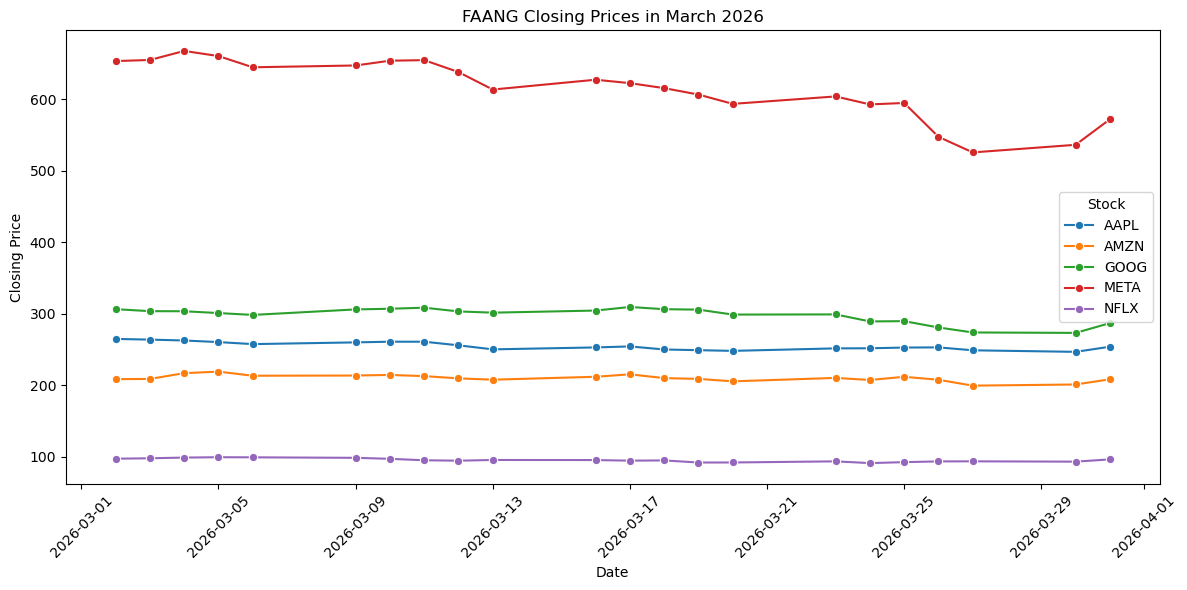

In [11]:
# Make sure data is sorted
market = market.sort_values(["symbol", "date"]).copy()

plt.figure(figsize=(12, 6))
sns.lineplot(data=market, x="date", y="close", hue="symbol", marker="o")

plt.title("FAANG Closing Prices in March 2026")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend(title="Stock")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

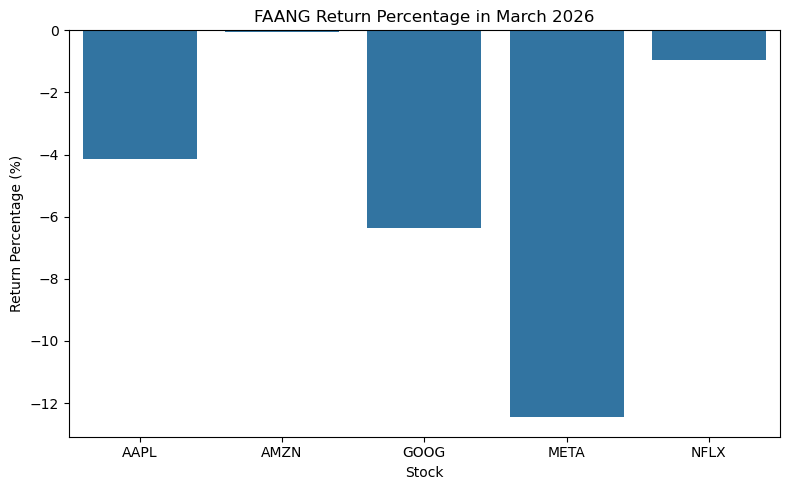

In [13]:
# b) Bar plot of monthly return percentage
# Reset index so seaborn can use it easily
monthly_returns_reset = monthly_returns.reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=monthly_returns_reset, x="symbol", y="return_pct")

plt.title("FAANG Return Percentage in March 2026")
plt.xlabel("Stock")
plt.ylabel("Return Percentage (%)")
plt.tight_layout()
plt.show()

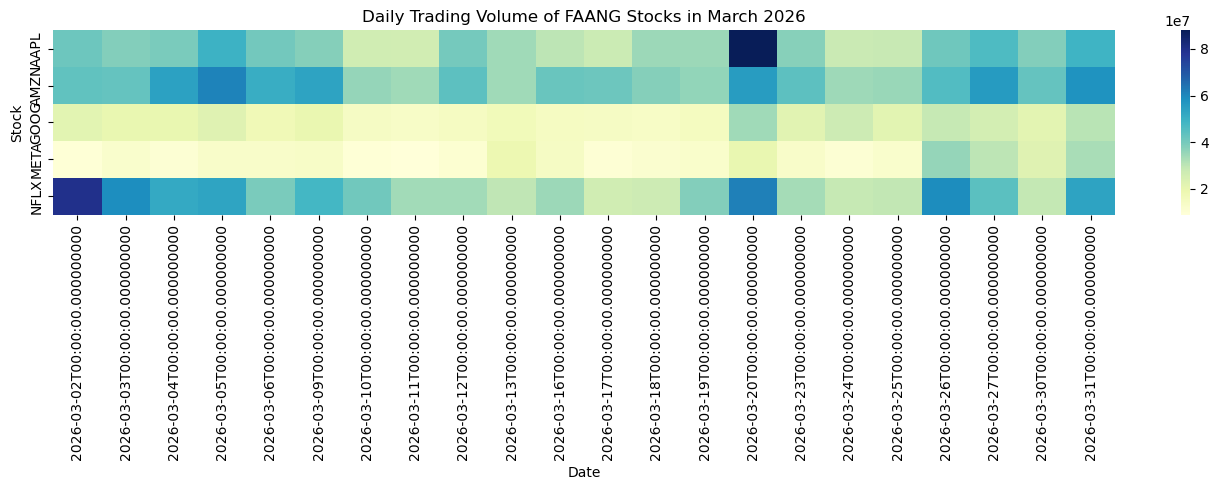

In [14]:
# c) Heatmap of daily trading volume
# Create pivot table for heatmap
volume_heatmap = market.pivot(index="symbol", columns="date", values="volume")

plt.figure(figsize=(14, 5))
sns.heatmap(volume_heatmap, cmap="YlGnBu")

plt.title("Daily Trading Volume of FAANG Stocks in March 2026")
plt.xlabel("Date")
plt.ylabel("Stock")
plt.tight_layout()
plt.show()

#### Task 4: Exporting and importing data

In [15]:
# a) Export JSON data
import os
import json

# Create exports folder if it doesn't exist
os.makedirs("exports", exist_ok=True)

# Save JSON data
with open("exports/stockdata.json", "w") as f:
    json.dump(data, f)

print("JSON file saved successfully.")

JSON file saved successfully.


In [16]:
# b) Export DataFrame as CSV
# Save DataFrame as CSV
df_market.to_csv("exports/stockdata.csv", index=False)

print("CSV file saved successfully.")

CSV file saved successfully.


In [17]:
# c) Load JSON back
with open("exports/stockdata.json", "r") as f:
    json_data_loaded = json.load(f)

# Convert to DataFrame
df_json_loaded = pd.DataFrame(json_data_loaded["data"])

print("Loaded JSON data:")
display(df_json_loaded.head())

Loaded JSON data:


,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,name,exchange_code,asset_type,price_currency,symbol,exchange,date
0,262.44,266.53,260.20,264.72,41576035.0,266.53,260.20,264.72,262.410,41827946.0,1.0,0.0,Apple Inc,NASDAQ,Stock,USD,AAPL,XNAS,2026-03-02T00:00:00+0000
1,204.55,209.72,203.48,208.39,43410499.0,209.73,203.46,208.39,204.550,46001010.0,1.0,0.0,Amazon.com Inc,NASDAQ,Stock,USD,AMZN,XNAS,2026-03-02T00:00:00+0000
2,302.93,308.14,301.06,306.36,21789144.0,308.14,301.06,306.36,302.965,21854368.0,1.0,0.0,1X GOOG,None,ETF,EUR,GOOG,XNAS,2026-03-02T00:00:00+0000
3,637.16,659.94,634.50,653.56,9801700.0,659.94,634.50,653.56,637.160,9816125.0,1.0,0.0,"Meta Platforms, Inc.",None,Stock,ARS,META,ARCX,2026-03-02T00:00:00+0000
4,95.33,98.07,95.25,97.09,79614084.0,98.07,95.20,97.09,95.260,79915361.0,1.0,0.0,NETFLIX INC,None,None,MXN,NFLX,XNAS,2026-03-02T00:00:00+0000


In [19]:
# Load CSV back
df_csv_loaded = pd.read_csv("exports/stockdata.csv")

print("Loaded CSV data:")
display(df_csv_loaded.head())

Loaded CSV data:


,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,name,exchange_code,asset_type,price_currency,symbol,exchange,date
0,262.44,266.53,260.20,264.72,41576035.0,266.53,260.20,264.72,262.410,41827946.0,1.0,0.0,Apple Inc,NASDAQ,Stock,USD,AAPL,XNAS,2026-03-02T00:00:00+0000
1,204.55,209.72,203.48,208.39,43410499.0,209.73,203.46,208.39,204.550,46001010.0,1.0,0.0,Amazon.com Inc,NASDAQ,Stock,USD,AMZN,XNAS,2026-03-02T00:00:00+0000
2,302.93,308.14,301.06,306.36,21789144.0,308.14,301.06,306.36,302.965,21854368.0,1.0,0.0,1X GOOG,NaN,ETF,EUR,GOOG,XNAS,2026-03-02T00:00:00+0000
3,637.16,659.94,634.50,653.56,9801700.0,659.94,634.50,653.56,637.160,9816125.0,1.0,0.0,"Meta Platforms, Inc.",NaN,Stock,ARS,META,ARCX,2026-03-02T00:00:00+0000
4,95.33,98.07,95.25,97.09,79614084.0,98.07,95.20,97.09,95.260,79915361.0,1.0,0.0,NETFLIX INC,NaN,NaN,MXN,NFLX,XNAS,2026-03-02T00:00:00+0000


#### Task 5: Querying the Northwind database

In [45]:
# a) Connect to the database
import sqlite3
import pandas as pd
from IPython.display import display

# Use the correct file name
conn = sqlite3.connect("data/northwind.db")

In [42]:
tables_df = pd.read_sql_query("""
SELECT name
FROM sqlite_master
WHERE type='table';
""", conn)

print("Tables in the Northwind database:")
display(tables_df)

Tables in the Northwind database:


,name
0,Categories
1,sqlite_sequence
2,CustomerCustomerDemo
3,CustomerDemographics
4,Customers
5,Employees
6,EmployeeTerritories
7,Order Details
8,Orders
9,Products


In [46]:
# b) 
query_b = """
SELECT ProductName, UnitPrice, UnitsInStock
FROM Products
WHERE UnitPrice > 30;
"""

products_above_30 = pd.read_sql_query(query_b, conn)

print("Products with UnitPrice above 30:")
display(products_above_30)

Products with UnitPrice above 30:


,ProductName,UnitPrice,UnitsInStock
0,Northwoods Cranberry Sauce,40.00,6
1,Mishi Kobe Niku,97.00,29
2,Ikura,31.00,31
3,Queso Manchego La Pastora,38.00,86
4,Alice Mutton,39.00,0
5,Carnarvon Tigers,62.50,42
6,Sir Rodney's Marmalade,81.00,40
7,Gumbär Gummibärchen,31.23,15
8,Schoggi Schokolade,43.90,49
9,Rössle Sauerkraut,45.60,26


In [47]:
# c)
query_c = """
SELECT c.CompanyName,
       o.OrderID,
       o.OrderDate,
       o.ShipCountry,
       od.UnitPrice * od.Quantity AS LineTotal
FROM Orders o
JOIN Customers c
    ON o.CustomerID = c.CustomerID
JOIN "Order Details" od
    ON o.OrderID = od.OrderID
WHERE o.ShipCountry = 'Germany';
"""

germany_orders = pd.read_sql_query(query_c, conn)

print("Orders shipped to Germany:")
display(germany_orders)

Orders shipped to Germany:


,CompanyName,OrderID,OrderDate,ShipCountry,LineTotal
0,Toms Spezialitäten,10249,2016-07-05,Germany,167.4
1,Toms Spezialitäten,10249,2016-07-05,Germany,1696.0
2,Ottilies Käseladen,10260,2016-07-19,Germany,123.2
3,Ottilies Käseladen,10260,2016-07-19,Germany,780.0
4,Ottilies Käseladen,10260,2016-07-19,Germany,591.0
...,...,...,...,...,...
80668,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,864.0
80669,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,735.0
80670,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,75.0
80671,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,500.0


#### Task 6: Visualizing Northwind data

In [48]:
# a) Number of orders per customer (top 10 customer shipped to Germany)
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

In [49]:
# Count unique orders per customer
orders_per_customer = (
    germany_orders.groupby("CompanyName")["OrderID"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name="NumberOfOrders")
)

display(orders_per_customer)

,CompanyName,NumberOfOrders
0,QUICK-Stop,56
1,Ottilies Käseladen,40
2,IT,40
3,Frankenversand,38
4,Königlich Essen,36
5,Great Lakes Food Market,35
6,Toms Spezialitäten,35
7,Lehmanns Marktstand,34
8,B's Beverages,32
9,Island Trading,31


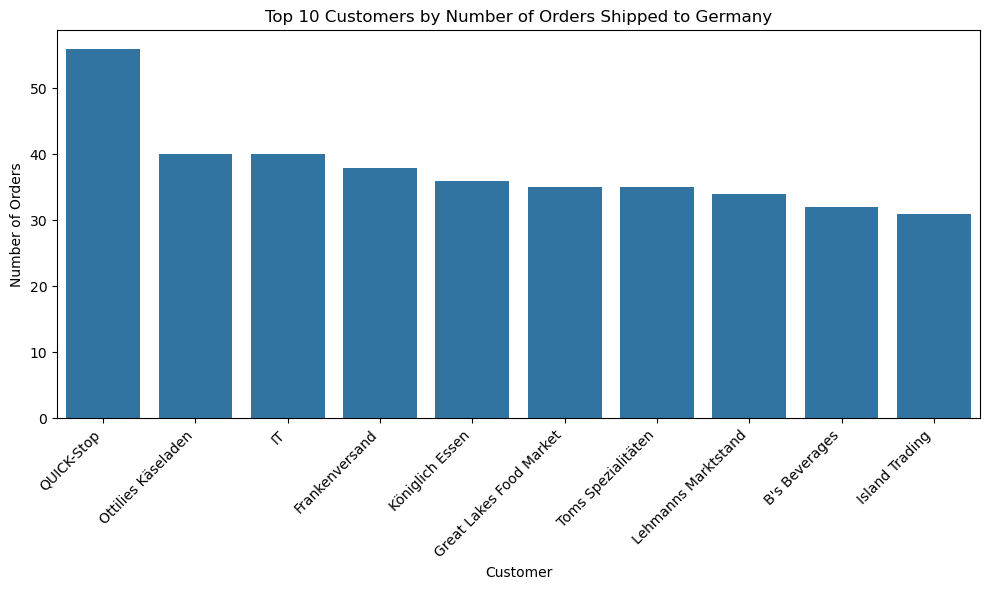

In [50]:
plt.figure(figsize=(10, 6))
sns.barplot(data=orders_per_customer, x="CompanyName", y="NumberOfOrders")

plt.title("Top 10 Customers by Number of Orders Shipped to Germany")
plt.xlabel("Customer")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [53]:
# b) Density plot of daily total sales for orders shipped to Germany
# Make sure OrderDate is datetime
germany_orders["OrderDate"] = pd.to_datetime(germany_orders["OrderDate"], format="mixed")

# Keep only the date part
germany_orders["OrderDate"] = germany_orders["OrderDate"].dt.date

# Compute daily total sales
daily_sales = (
    germany_orders.groupby("OrderDate")["LineTotal"]
    .sum()
    .reset_index(name="DailyTotalSales")
)

display(daily_sales.head())

,OrderDate,DailyTotalSales
0,2012-07-16,21857.43
1,2012-07-18,53885.01
2,2012-07-25,18591.01
3,2012-07-30,60918.92
4,2012-07-31,55931.37


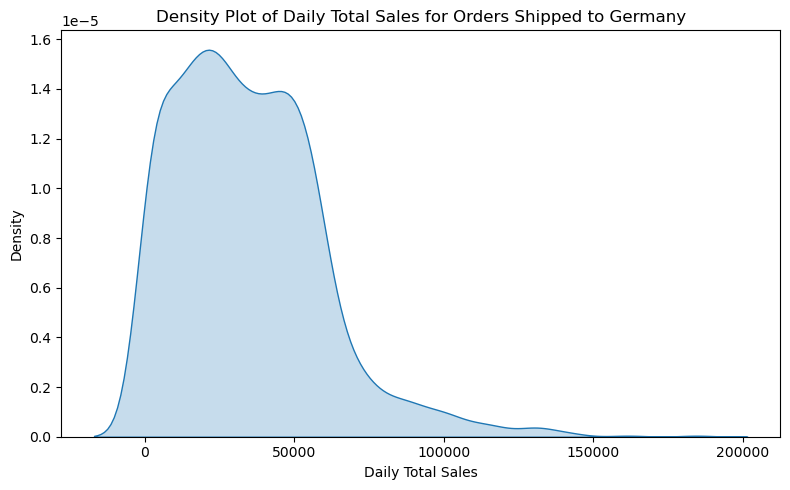

In [54]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=daily_sales, x="DailyTotalSales", fill=True)

plt.title("Density Plot of Daily Total Sales for Orders Shipped to Germany")
plt.xlabel("Daily Total Sales")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

In [55]:
# c) Total revenue by product category
query_6c = """
SELECT c.CategoryName,
       SUM(od.UnitPrice * od.Quantity) AS TotalRevenue
FROM "Order Details" od
JOIN Products p
    ON od.ProductID = p.ProductID
JOIN Categories c
    ON p.CategoryID = c.CategoryID
GROUP BY c.CategoryName
ORDER BY TotalRevenue DESC;
"""

category_revenue = pd.read_sql_query(query_6c, conn)

print("Total revenue by category:")
display(category_revenue)

Total revenue by category:


,CategoryName,TotalRevenue
0,Beverages,92181842.95
1,Confections,66347544.94
2,Meat/Poultry,64896314.41
3,Dairy Products,58034940.00
4,Condiments,55802774.45
5,Seafood,49931965.52
6,Produce,32706403.90
7,Grains/Cereals,28573512.55


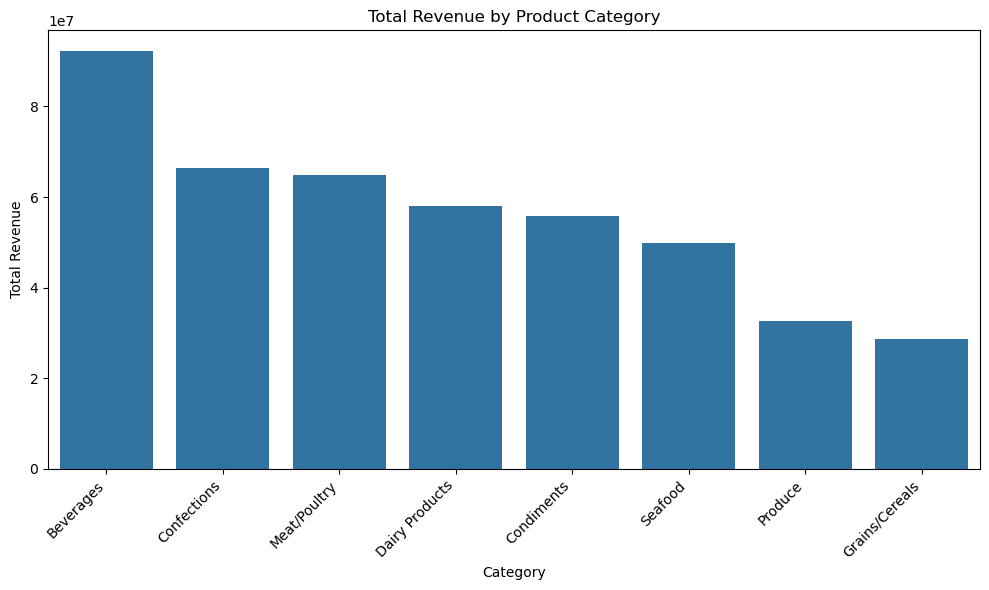

In [56]:
plt.figure(figsize=(10, 6))
sns.barplot(data=category_revenue, x="CategoryName", y="TotalRevenue")

plt.title("Total Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

#### Task 7: Comparing Python to SQL

In [63]:
# a) Retrieve full Products and Categories tables into separate DataFrames
# Full Products table
products_df = pd.read_sql_query("SELECT * FROM Products;", conn)

print("First 5 rows of Products:")
display(products_df.head())

First 5 rows of Products:


,ProductID,ProductName,SupplierID,CategoryID,QuantityPerUnit,UnitPrice,UnitsInStock,UnitsOnOrder,ReorderLevel,Discontinued
0,1,Chai,1,1,10 boxes x 20 bags,18.00,39,0,10,0
1,2,Chang,1,1,24 - 12 oz bottles,19.00,17,40,25,0
2,3,Aniseed Syrup,1,2,12 - 550 ml bottles,10.00,13,70,25,0
3,4,Chef Anton's Cajun Seasoning,2,2,48 - 6 oz jars,22.00,53,0,0,0
4,5,Chef Anton's Gumbo Mix,2,2,36 boxes,21.35,0,0,0,1


In [58]:
# Full Categories table
categories_df = pd.read_sql_query("SELECT * FROM Categories;", conn)

print("First 5 rows of Categories:")
display(categories_df.head())

First 5 rows of Categories:


,CategoryID,CategoryName,Description,Picture
0,1,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
1,2,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
2,3,Confections,"Desserts, candies, and sweet breads",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
3,4,Dairy Products,Cheeses,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
4,5,Grains/Cereals,"Breads, crackers, pasta, and cereal",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...


In [64]:
# b) Inner join in pandas on CategoryID
products_categories_joined = pd.merge(
    products_df,
    categories_df,
    on="CategoryID",
    how="inner"
)

print("Joined Products and Categories:")
display(products_categories_joined.head())

Joined Products and Categories:


,ProductID,ProductName,SupplierID,CategoryID,QuantityPerUnit,UnitPrice,UnitsInStock,UnitsOnOrder,ReorderLevel,Discontinued,CategoryName,Description,Picture
0,1,Chai,1,1,10 boxes x 20 bags,18.00,39,0,10,0,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
1,2,Chang,1,1,24 - 12 oz bottles,19.00,17,40,25,0,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
2,3,Aniseed Syrup,1,2,12 - 550 ml bottles,10.00,13,70,25,0,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
3,4,Chef Anton's Cajun Seasoning,2,2,48 - 6 oz jars,22.00,53,0,0,0,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
4,5,Chef Anton's Gumbo Mix,2,2,36 boxes,21.35,0,0,0,1,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...


In [66]:
# c) Compare SQL vs pandas execution speed
# SQL timing
import time

start_sql = time.time()

query_sql = """
SELECT c.CategoryName,
       SUM(od.UnitPrice * od.Quantity) AS TotalRevenue
FROM "Order Details" od
JOIN Products p
    ON od.ProductID = p.ProductID
JOIN Categories c
    ON p.CategoryID = c.CategoryID
GROUP BY c.CategoryName
ORDER BY TotalRevenue DESC;
"""

sql_result = pd.read_sql_query(query_sql, conn)

end_sql = time.time()
sql_time = end_sql - start_sql

print("SQL result:")
display(sql_result)

print(f"SQL execution time: {sql_time:.6f} seconds")

SQL result:


,CategoryName,TotalRevenue
0,Beverages,92181842.95
1,Confections,66347544.94
2,Meat/Poultry,64896314.41
3,Dairy Products,58034940.00
4,Condiments,55802774.45
5,Seafood,49931965.52
6,Produce,32706403.90
7,Grains/Cereals,28573512.55


SQL execution time: 0.393007 seconds


In [67]:
# pandas timing
start_py = time.time()

# Load full tables
order_details_df = pd.read_sql_query('SELECT * FROM "Order Details";', conn)
products_df = pd.read_sql_query("SELECT * FROM Products;", conn)
categories_df = pd.read_sql_query("SELECT * FROM Categories;", conn)

# Inner joins in pandas
merged_df = pd.merge(order_details_df, products_df, on="ProductID", how="inner")
merged_df = pd.merge(merged_df, categories_df, on="CategoryID", how="inner")

# Compute total revenue per category
python_result = (
    merged_df.assign(LineRevenue=merged_df["UnitPrice_x"] * merged_df["Quantity"])
    .groupby("CategoryName", as_index=False)["LineRevenue"]
    .sum()
    .rename(columns={"LineRevenue": "TotalRevenue"})
    .sort_values("TotalRevenue", ascending=False)
)

end_py = time.time()
python_time = end_py - start_py

print("Python/pandas result:")
display(python_result)

print(f"Python execution time: {python_time:.6f} seconds")

Python/pandas result:


,CategoryName,TotalRevenue
0,Beverages,92181842.95
2,Confections,66347544.94
5,Meat/Poultry,64896314.41
3,Dairy Products,58034940.00
1,Condiments,55802774.45
7,Seafood,49931965.52
6,Produce,32706403.90
4,Grains/Cereals,28573512.55


Python execution time: 1.058319 seconds


In [62]:
# Compare times
print(f"SQL execution time: {sql_time:.6f} seconds")
print(f"Python execution time: {python_time:.6f} seconds")

if sql_time < python_time:
    print("SQL was faster.")
elif python_time < sql_time:
    print("Python/pandas was faster.")
else:
    print("Both had the same execution time.")

SQL execution time: 0.408595 seconds
Python execution time: 1.107177 seconds
SQL was faster.


#### Task 8: Wide and long format

In [68]:
# a) Convert wide_data from wide to long using pd.melt()
import pandas as pd
from IPython.display import display

In [69]:
wide_data = pd.DataFrame({
    "store": ["Helsinki", "Tampere", "Turku"],
    "Q1_sales": [12000, 8500, 9200],
    "Q2_sales": [13500, 9100, 9800],
    "Q3_sales": [11800, 8800, 10100],
    "Q4_sales": [15000, 10200, 11500]
})

print("Wide data before conversion:")
display(wide_data)

Wide data before conversion:


,store,Q1_sales,Q2_sales,Q3_sales,Q4_sales
0,Helsinki,12000,13500,11800,15000
1,Tampere,8500,9100,8800,10200
2,Turku,9200,9800,10100,11500


In [70]:
wide_to_long = pd.melt(
    wide_data,
    id_vars="store",
    var_name="quarter",
    value_name="sales"
)

print("Wide data after conversion to long format:")
display(wide_to_long)

Wide data after conversion to long format:


,store,quarter,sales
0,Helsinki,Q1_sales,12000
1,Tampere,Q1_sales,8500
2,Turku,Q1_sales,9200
3,Helsinki,Q2_sales,13500
4,Tampere,Q2_sales,9100
5,Turku,Q2_sales,9800
6,Helsinki,Q3_sales,11800
7,Tampere,Q3_sales,8800
8,Turku,Q3_sales,10100
9,Helsinki,Q4_sales,15000


In [71]:
# b) Convert long_data from long to wide using .pivot()
long_data = pd.DataFrame({
    "month": ["Jan", "Jan", "Feb", "Feb", "Mar", "Mar"],
    "product": ["Laptop", "Phone", "Laptop", "Phone", "Laptop", "Phone"],
    "units_sold": [45, 120, 50, 110, 55, 130]
})

print("Long data before conversion:")
display(long_data)

Long data before conversion:


,month,product,units_sold
0,Jan,Laptop,45
1,Jan,Phone,120
2,Feb,Laptop,50
3,Feb,Phone,110
4,Mar,Laptop,55
5,Mar,Phone,130


In [72]:
long_to_wide = long_data.pivot(
    index="month",
    columns="product",
    values="units_sold"
).reset_index()

print("Long data after conversion to wide format:")
display(long_to_wide)

Long data after conversion to wide format:


product,month,Laptop,Phone
0,Feb,50,110
1,Jan,45,120
2,Mar,55,130


In [73]:
# c) Convert both transformed datasets back to original format
# Convert wide_to_long back to original wide format
long_back_to_wide = wide_to_long.pivot(
    index="store",
    columns="quarter",
    values="sales"
).reset_index()

# Remove the columns name left by pivot
long_back_to_wide.columns.name = None

print("Converted back to original wide format:")
display(long_back_to_wide)

Converted back to original wide format:


,store,Q1_sales,Q2_sales,Q3_sales,Q4_sales
0,Helsinki,12000,13500,11800,15000
1,Tampere,8500,9100,8800,10200
2,Turku,9200,9800,10100,11500


In [74]:
# Convert long_to_wide back to original long format
wide_back_to_long = pd.melt(
    long_to_wide,
    id_vars="month",
    var_name="product",
    value_name="units_sold"
)

# Optional: sort rows to match original order better
wide_back_to_long = wide_back_to_long.sort_values(["month", "product"]).reset_index(drop=True)

print("Converted back to original long format:")
display(wide_back_to_long)

Converted back to original long format:


,month,product,units_sold
0,Feb,Laptop,50
1,Feb,Phone,110
2,Jan,Laptop,45
3,Jan,Phone,120
4,Mar,Laptop,55
5,Mar,Phone,130


In [75]:
# Show originals again for comparison
print("Original wide_data:")
display(wide_data)

print("Reconstructed wide_data:")
display(long_back_to_wide)

print("Original long_data:")
display(long_data.sort_values(["month", "product"]).reset_index(drop=True))

print("Reconstructed long_data:")
display(wide_back_to_long)

Original wide_data:


,store,Q1_sales,Q2_sales,Q3_sales,Q4_sales
0,Helsinki,12000,13500,11800,15000
1,Tampere,8500,9100,8800,10200
2,Turku,9200,9800,10100,11500


Reconstructed wide_data:


,store,Q1_sales,Q2_sales,Q3_sales,Q4_sales
0,Helsinki,12000,13500,11800,15000
1,Tampere,8500,9100,8800,10200
2,Turku,9200,9800,10100,11500


Original long_data:


,month,product,units_sold
0,Feb,Laptop,50
1,Feb,Phone,110
2,Jan,Laptop,45
3,Jan,Phone,120
4,Mar,Laptop,55
5,Mar,Phone,130


Reconstructed long_data:


,month,product,units_sold
0,Feb,Laptop,50
1,Feb,Phone,110
2,Jan,Laptop,45
3,Jan,Phone,120
4,Mar,Laptop,55
5,Mar,Phone,130
